<a href="https://colab.research.google.com/github/hecfrantuis/Hands-on-Computer-Vision/blob/main/ProyectoIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0. Ejecutar al iniciar

In [6]:
from google.colab import drive
import os

drive.mount('/content/drive')
mi_ruta = '/content/drive/MyDrive/Septimo/IA 1 2026-1/Proyecto/AcneDataset/train'
os.chdir(mi_ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Librerias para el procesamiento de las imagenes

In [8]:
import cv2 # Para procesar imágenes (grises, rotación)
import numpy as np # Para cálculos estadísticos
import matplotlib.pyplot as plt # Para ver las fotos y gráficas
import seaborn as sns # Para que tus gráficas de color se vean profesionales
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder

# 1.Descarga de imaganes

Vincular Drive con Colab

In [ ]:
from google.colab import drive
import os

# 1. Montamos el Drive (Paso obligatorio)
drive.mount('/content/drive')

# 2. Definimos TU ubicación personalizada
# Cambia 'Clase_IA/Dataset_Acne' por el nombre de las carpetas que prefieras
mi_ruta_personalizada = '/content/drive/MyDrive/Septimo/IA 1 2026-1/Proyecto'

# 3. Creamos la carpeta si no existe
if not os.path.exists(mi_ruta_personalizada):
    os.makedirs(mi_ruta_personalizada)
    print(f"Carpeta creada en: {mi_ruta_personalizada}")

# 4. Nos movemos a esa ubicación
%cd $mi_ruta_personalizada

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Septimo/IA 1 2026-1/Proyecto


Configurar las credenciales de Kaggle

In [ ]:
# REEMPLAZA ESTOS DATOS
os.environ['KAGGLE_USERNAME'] = "hjfuis"
os.environ['KAGGLE_KEY'] = "KGAT_7067e701e235e3e2e8508df6820a675d"

# Esto crea el archivo automáticamente en la ubicación correcta
!mkdir -p ~/.kaggle
import json
data = {"username":os.environ['KAGGLE_USERNAME'], "key":os.environ['KAGGLE_KEY']}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(data, f)

!chmod 600 /root/.kaggle/kaggle.json
print("Archivo kaggle.json creado exitosamente.")

Archivo kaggle.json creado exitosamente.


Descargar y descomprimir el dataset en tu carpeta de Drive

In [ ]:
# 1. Define tu carpeta del proyecto (Cámbiala si prefieres otro nombre)
!mkdir -p "$mi_ruta_personalizada"
%cd "$mi_ruta_personalizada"

# 2. Descarga el dataset desde Kaggle
!kaggle datasets download -d tiswan14/acne-dataset-image

# 3. Descomprime (el parámetro -q lo hace en silencio y más rápido)
!unzip -q acne-dataset-image.zip
!rm acne-dataset-image.zip  # Borra el zip para ahorrar espacio en Drive
print("¡Hecho! Los archivos están en tu Drive.")

/content/drive/MyDrive/Septimo/IA 1 2026-1/Proyecto
Dataset URL: https://www.kaggle.com/datasets/tiswan14/acne-dataset-image
License(s): apache-2.0
 96% 117M/122M [00:00<00:00, 184MB/s] 
100% 122M/122M [00:00<00:00, 213MB/s]
¡Hecho! Los archivos están en tu Drive.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2.Validación del Dataset

In [9]:
# Configuración de estética "Premium"
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

Verificación el contenido

In [10]:
# Listar las carpetas (clases) y contar imágenes
categorias = [f for f in os.listdir('.') if os.path.isdir(f)]
conteo = {cat: len(os.listdir(cat)) for cat in categorias}

# Mostrar en una tabla simple
df_stats = pd.DataFrame(conteo.items(), columns=['Nivel de Acné', 'Cantidad de Imágenes'])
print(df_stats)

  Nivel de Acné  Cantidad de Imágenes
0    Blackheads                   735
1          Cyst                   645
2       Papules                   621
3      Pustules                   584
4    Whiteheads                   193


Análisis de Píxeles

In [11]:
dimensiones = []
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(root, file)
            img = cv2.imread(path)
            if img is not None:
                h, w, c = img.shape
                # Guardamos alto, ancho y la categoría (nombre de la carpeta)
                categoria = os.path.basename(root)
                dimensiones.append({'Categoria': categoria, 'Alto': h, 'Ancho': w, 'Pixeles_Totales': h*w})

df_dim = pd.DataFrame(dimensiones)

# Resumen estadístico para tu presentación
print("Resumen de dimensiones del dataset:")
print(df_dim.groupby('Categoria')[['Alto', 'Ancho']].describe())

Resumen de dimensiones del dataset:
             Alto                                                 Ancho  \
            count   mean  std    min    25%    50%    75%    max  count   
Categoria                                                                 
Blackheads  735.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  735.0   
Cyst        645.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  645.0   
Papules     621.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  621.0   
Pustules    584.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  584.0   
Whiteheads  193.0  640.0  0.0  640.0  640.0  640.0  640.0  640.0  193.0   

                                                           
             mean  std    min    25%    50%    75%    max  
Categoria                                                  
Blackheads  640.0  0.0  640.0  640.0  640.0  640.0  640.0  
Cyst        640.0  0.0  640.0  640.0  640.0  640.0  640.0  
Papules     640.0  0.0  640.0  640.0  640.0  640.0  640.0  
Pus

Extracción de Datos

In [12]:
def extraer_datos_proyecto(ruta_base, categorias, n_muestras=50):
    recolector = []

    for cat in categorias:
        folder = os.path.join(ruta_base, cat)
        if not os.path.isdir(folder): continue

        # Tomamos una muestra para que el proceso sea rápido
        imagenes = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.png', '.jpeg'))][:n_muestras]

        for img_name in imagenes:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                # 1. Color Promedio (RGB)
                avg_color = np.mean(img, axis=(0, 1))
                # 2. Contraste (Varianza en escala de grises)
                gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                contraste = np.var(gris)

                recolector.append({
                    'Categoria': cat,
                    'Rojo': avg_color[2],
                    'Verde': avg_color[1],
                    'Azul': avg_color[0],
                    'Contraste': contraste
                })

    return pd.DataFrame(recolector)

# --- EJECUCIÓN ---
# Asegúrate de que mi_ruta apunte a '.../AcneDataset/train'
categorias_acne = [f for f in os.listdir(mi_ruta) if os.path.isdir(os.path.join(mi_ruta, f))]
df_proyecto = extraer_datos_proyecto(mi_ruta, categorias_acne)

print("Datos extraídos con éxito. Filas generadas:", len(df_proyecto))

Datos extraídos con éxito. Filas generadas: 250


Distribución de Color (Análisis por Patología)

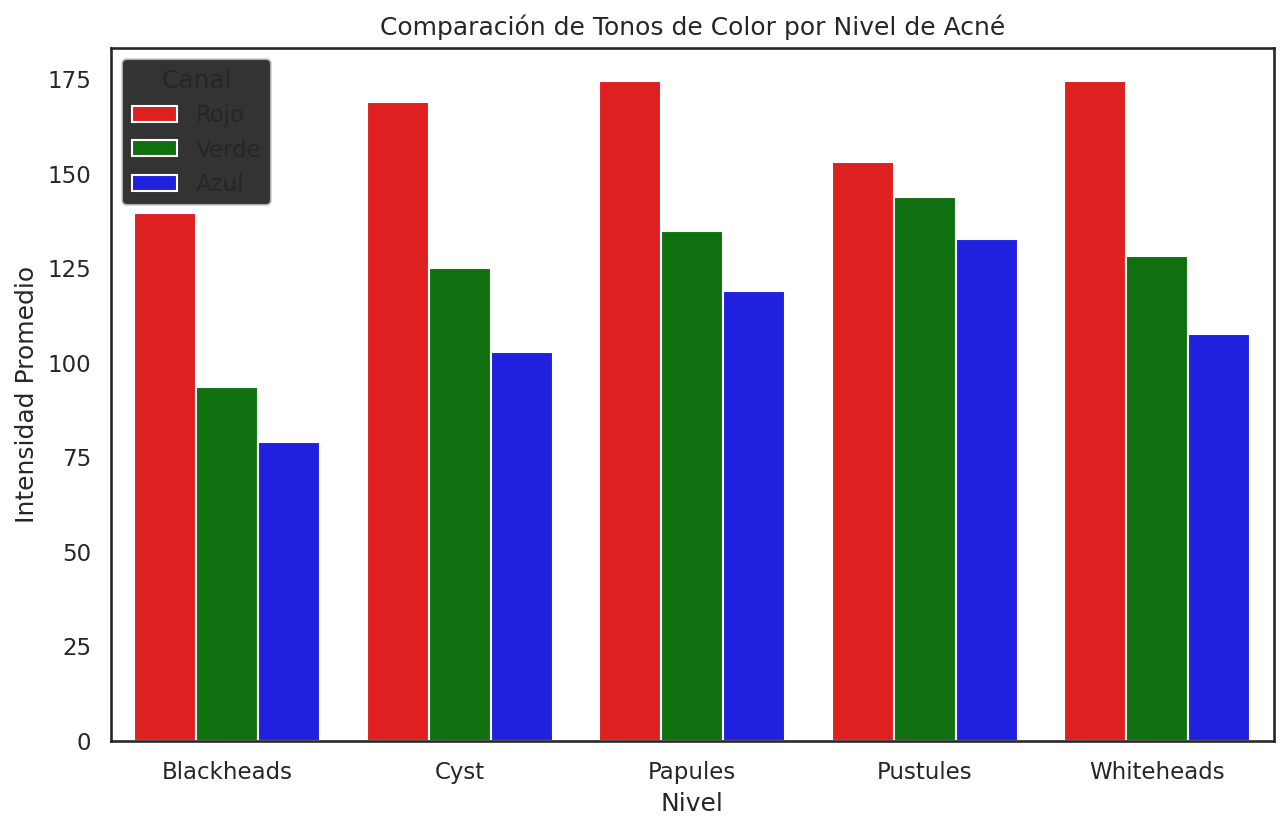

In [13]:
def analizar_color(ruta_imagen):
    img = cv2.imread(ruta_imagen)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Calculamos el promedio de cada canal (R, G, B)
    promedios = np.mean(img, axis=(0, 1))
    return promedios

# Tomamos una muestra de cada categoría para comparar
resultados_color = []
for cat in categorias:
    carpeta_cat = os.path.join(mi_ruta, cat)
    primera_img = os.path.join(carpeta_cat, os.listdir(carpeta_cat)[0])
    r, g, b = analizar_color(primera_img)
    resultados_color.append({'Nivel': cat, 'Rojo': r, 'Verde': g, 'Azul': b})

df_color = pd.DataFrame(resultados_color)

# Graficar para el avance del proyecto
plt.figure(figsize=(10, 6))
df_melt = df_color.melt(id_vars='Nivel', var_name='Canal', value_name='Intensidad Promedio')
sns.barplot(data=df_melt, x='Nivel', y='Intensidad Promedio', hue='Canal', palette=['red', 'green', 'blue'])
plt.title("Comparación de Tonos de Color por Nivel de Acné")
plt.show()

Histogramas Comparativos de color

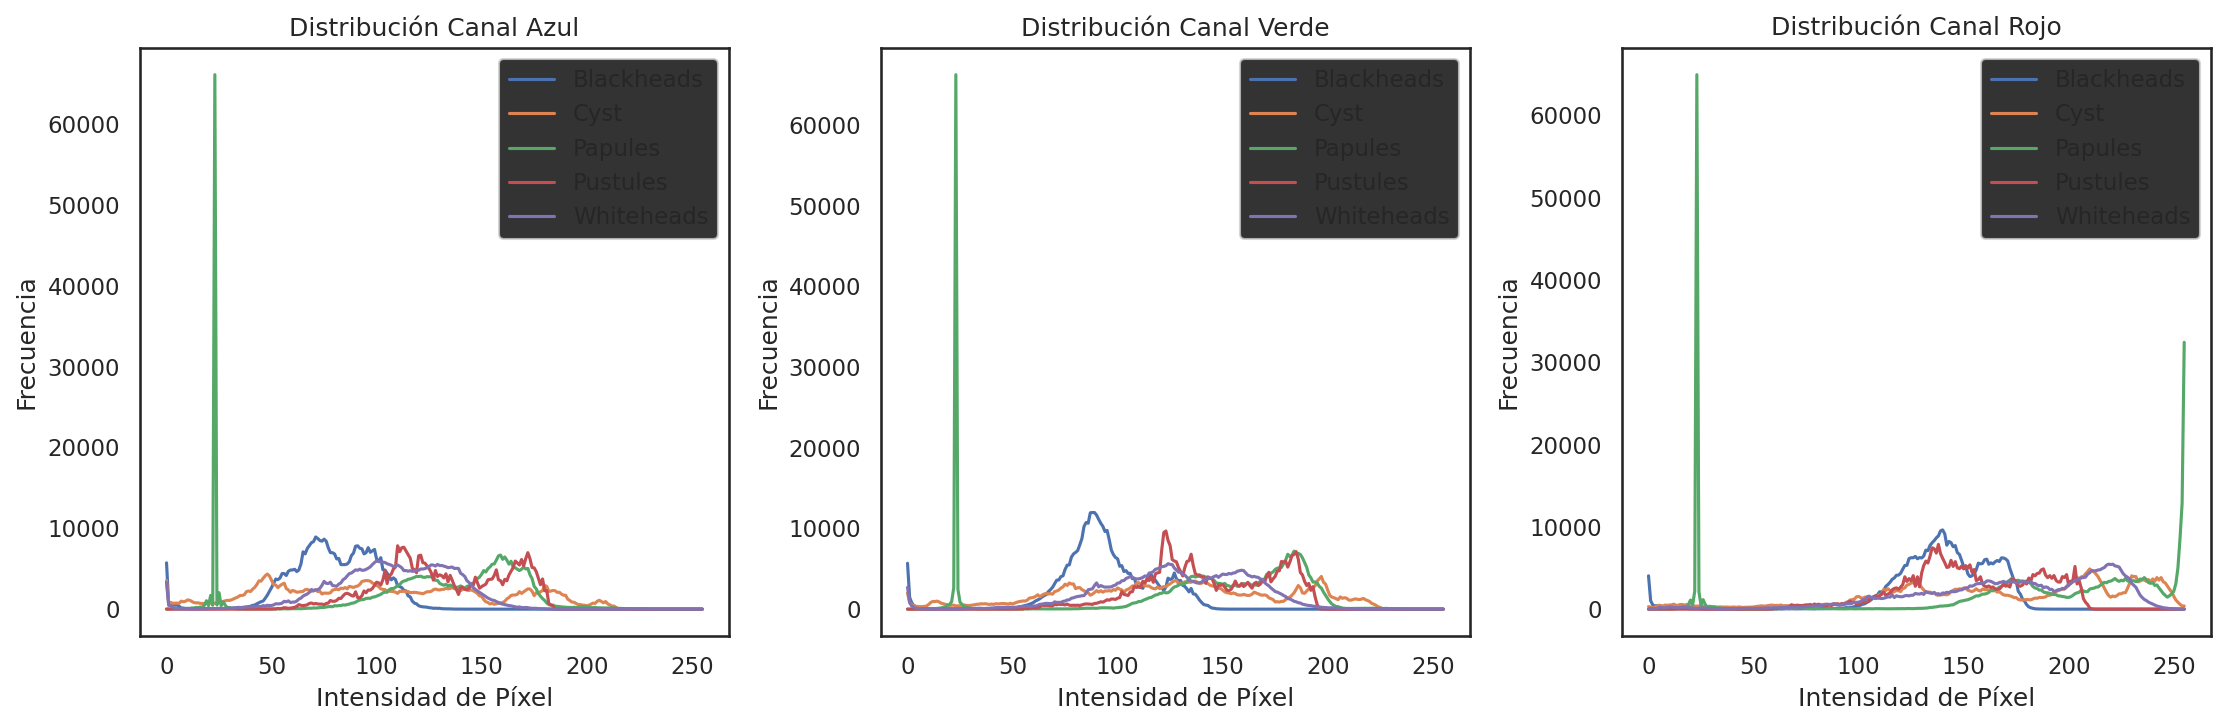

In [14]:
def graficar_comparativa_histogramas(ruta_base, categorias):
    plt.figure(figsize=(15, 5))
    colores = ('b', 'g', 'r')
    nombres_canales = ('Azul', 'Verde', 'Rojo')

    for i, col in enumerate(colores):
        plt.subplot(1, 3, i+1)
        for cat in categorias:
            # Tomamos una imagen representativa de cada carpeta
            folder = os.path.join(ruta_base, cat)
            img_name = os.listdir(folder)[0]
            img = cv2.imread(os.path.join(folder, img_name))

            # Calcular histograma para el canal actual
            hist = cv2.calcHist([img], [i], None, [256], [0, 256])
            plt.plot(hist, label=cat)

        plt.title(f'Distribución Canal {nombres_canales[i]}')
        plt.xlabel('Intensidad de Píxel')
        plt.ylabel('Frecuencia')
        plt.legend()

    plt.tight_layout()
    plt.show()

categorias = ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']
graficar_comparativa_histogramas(mi_ruta, categorias)

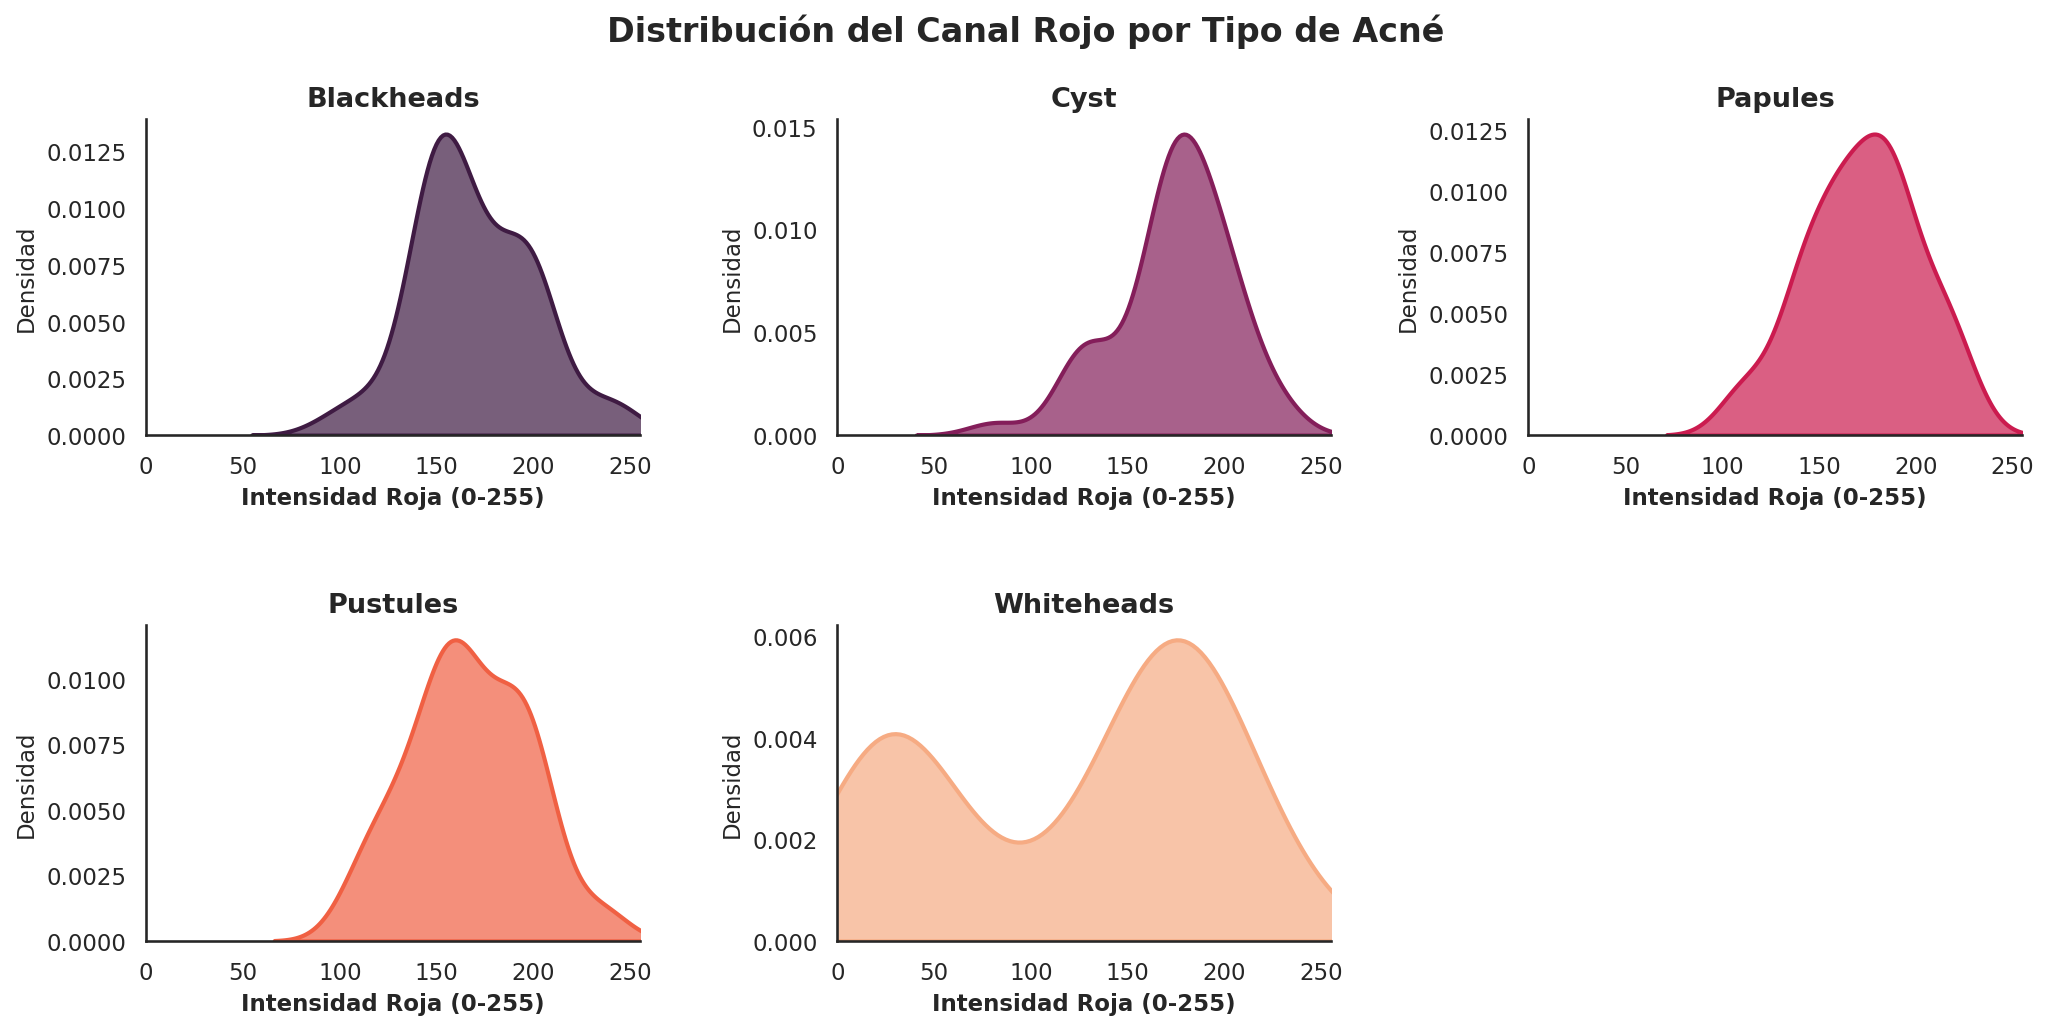

In [15]:
def grafico_distribucion_clara(df):
    # Agregamos sharex=False y sharey=False para que Seaborn las trate como gráficas independientes
    g = sns.FacetGrid(df, col="Categoria", hue="Categoria", col_wrap=3,
                      palette="rocket", height=3.5, aspect=1.3, sharex=False, sharey=False)

    # Dibujamos la densidad
    g.map(sns.kdeplot, "Rojo", fill=True, alpha=0.7, linewidth=2)

    # Títulos individuales
    g.set_titles("{col_name}", fontweight='bold', size=13)

    # --- LA SOLUCIÓN DEFINITIVA ---
    for ax in g.axes.flatten():
        ax.set_xlim(0, 255) # Límite real del color
        # Forzamos los textos en CADA una de las gráficas
        ax.set_xlabel("Intensidad Roja (0-255)", fontsize=11, fontweight='bold')
        ax.set_ylabel("Densidad", fontsize=11)
    # ------------------------------

    # Aumentamos wspace (espacio horizontal) y hspace (vertical) para que los textos no choquen
    plt.subplots_adjust(top=0.88, hspace=0.6, wspace=0.4)

    g.fig.suptitle('Distribución del Canal Rojo por Tipo de Acné', fontsize=16, fontweight='bold')
    plt.show()

grafico_distribucion_clara(df_proyecto)

Boxplots de Intensidad por Canal

/tmp/ipykernel_1774/2137147163.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Categoria', y='Rojo', inner=None, palette="rocket", alpha=0.6)


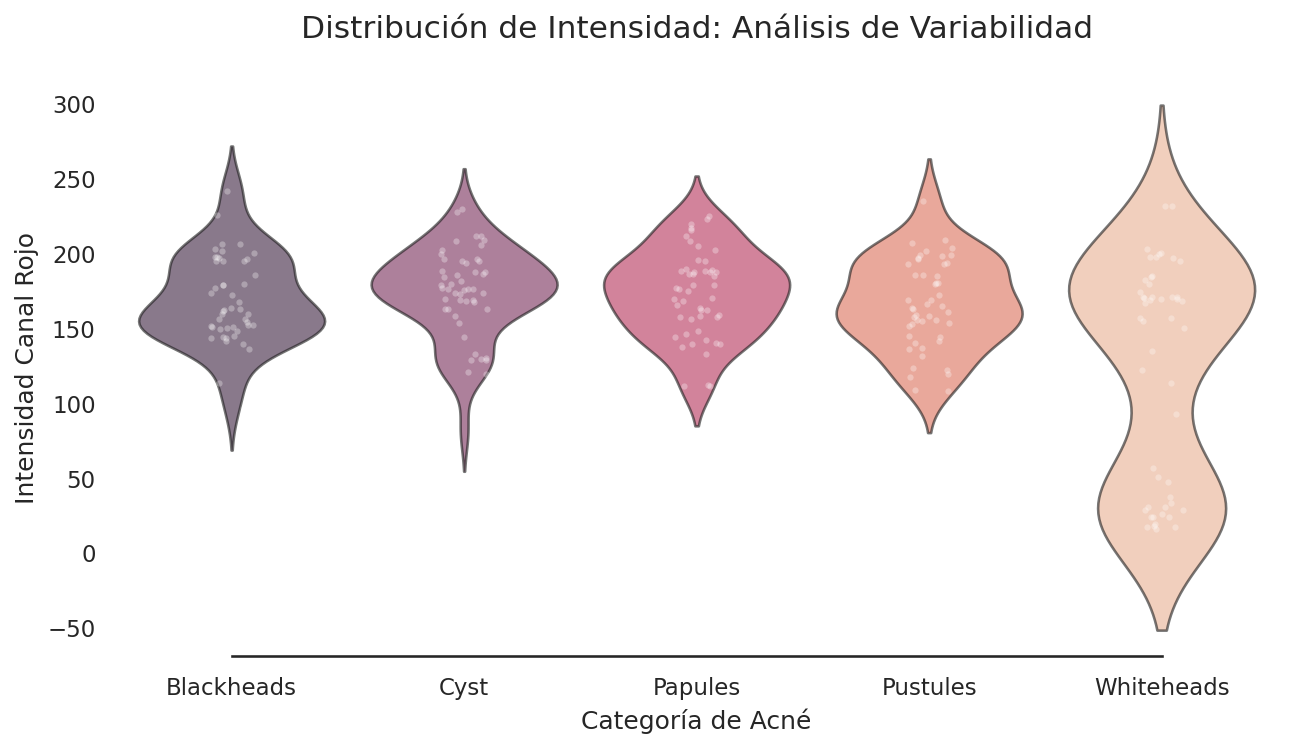

In [16]:
def grafico_violin_impacto(df):
    plt.figure(figsize=(10, 5))

    # El violín muestra la densidad
    sns.violinplot(data=df, x='Categoria', y='Rojo', inner=None, palette="rocket", alpha=0.6)

    # Superponemos los puntos reales (jitter) para ver la muestra completa
    sns.stripplot(data=df, x='Categoria', y='Rojo', color="white", edgecolor="black",
                  size=3, alpha=0.3, jitter=True)

    plt.title("Distribución de Intensidad: Análisis de Variabilidad", fontsize=15, pad=20)
    plt.xlabel("Categoría de Acné", fontsize=12)
    plt.ylabel("Intensidad Canal Rojo", fontsize=12)
    sns.despine(trim=True, left=True)
    plt.show()

grafico_violin_impacto(df_proyecto)

Análisis de Contraste (Varianza de Grises)

/tmp/ipykernel_1774/1998093549.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Categoria', y='Contraste', data=df_cont, palette="Greys_r")


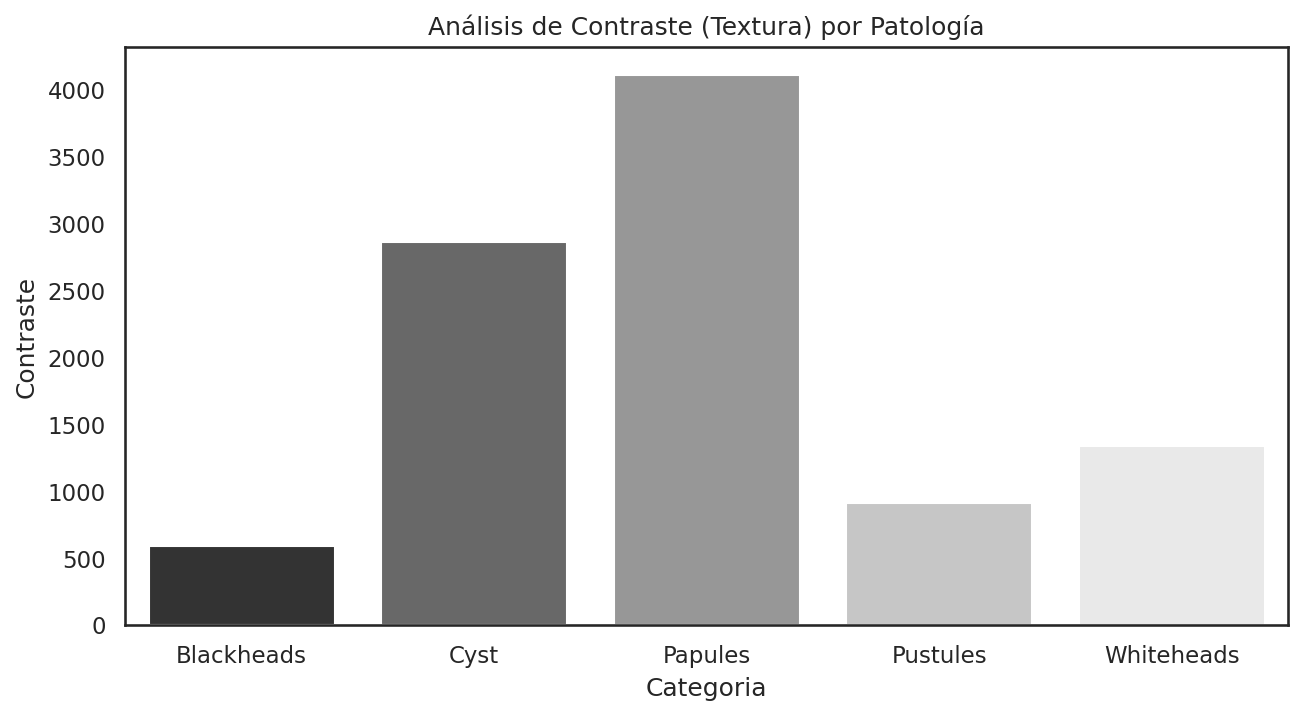

In [17]:
def analizar_contraste(ruta_datos, categorias):
    contraste_resultados = []

    for cat in categorias:
        folder = os.path.join(ruta_datos, cat)
        img_name = os.listdir(folder)[0]
        img = cv2.imread(os.path.join(folder, img_name), cv2.IMREAD_GRAYSCALE)

        # La varianza es una medida de contraste
        varianza = np.var(img)
        contraste_resultados.append({'Categoria': cat, 'Contraste': varianza})

    df_cont = pd.DataFrame(contraste_resultados)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='Categoria', y='Contraste', data=df_cont, palette="Greys_r")
    plt.title('Análisis de Contraste (Textura) por Patología')
    plt.show()

analizar_contraste(mi_ruta, categorias)

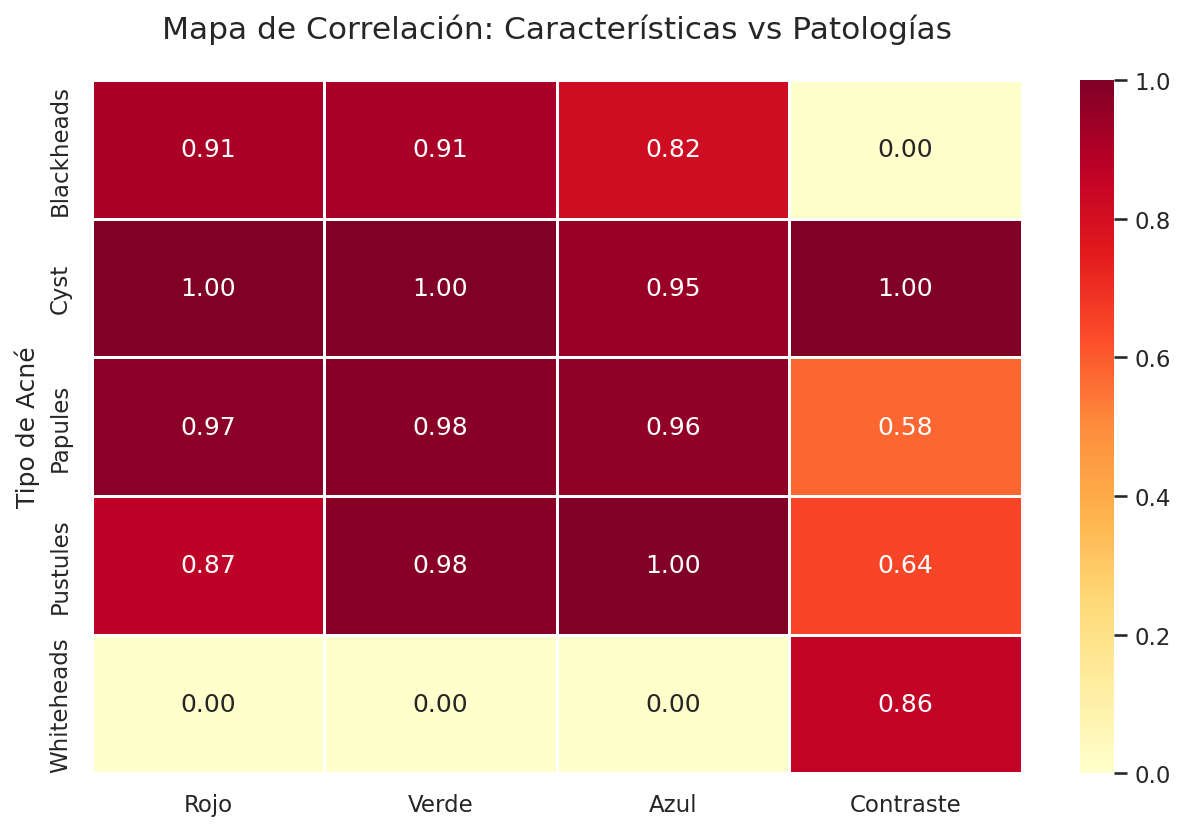

In [18]:
def grafico_heatmap_correlacion(df):
    # Agrupamos por categoría y sacamos el promedio
    df_resumen = df.groupby('Categoria').mean()

    # Normalizamos para que la comparación sea visualmente clara (0 a 1)
    df_norm = (df_resumen - df_resumen.min()) / (df_resumen.max() - df_resumen.min())

    plt.figure(figsize=(10, 6))
    sns.heatmap(df_norm, annot=True, cmap="YlOrRd", fmt=".2f", linewidths=.5)

    plt.title("Mapa de Correlación: Características vs Patologías", fontsize=15, pad=20)
    plt.ylabel("Tipo de Acné")
    plt.show()

grafico_heatmap_correlacion(df_proyecto)

Visualización de Procesamiento (Original vs. Transformada)

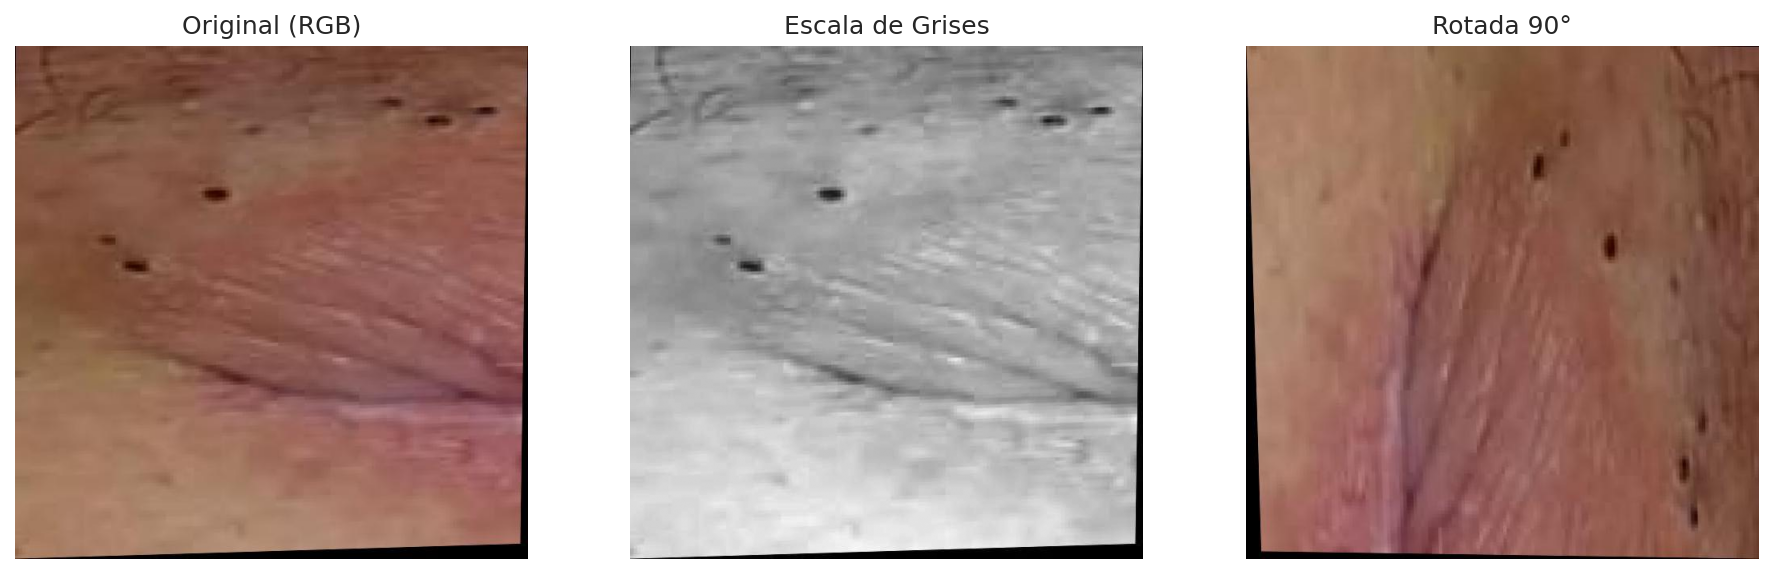

In [19]:
# Elegir una imagen de prueba
img_prueba_path = os.path.join(mi_ruta, categorias[0], os.listdir(categorias[0])[0])
img_original = cv2.imread(img_prueba_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# Procesamiento
img_gris = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)
img_rotada = cv2.rotate(img_original, cv2.ROTATE_90_CLOCKWISE)

# Mostrar resultados en una sola fila
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_original)
ax[0].set_title("Original (RGB)")
ax[1].imshow(img_gris, cmap='gray')
ax[1].set_title("Escala de Grises")
ax[2].imshow(img_rotada)
ax[2].set_title("Rotada 90°")
for a in ax: a.axis('off')
plt.show()

# 3. selección de datos

0. Construir el DataFrame con las etiquetas

In [20]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import local_binary_pattern
from scipy.stats import entropy

data = []

for etiqueta in os.listdir('.'):
    if os.path.isdir(etiqueta):
        for archivo in os.listdir(etiqueta):
            if archivo.endswith(('.jpg', '.png')):
                ruta_completa = os.path.join(etiqueta, archivo)
                img_bgr = cv2.imread(ruta_completa)

                if img_bgr is None:
                    continue

                # ── RGB ──────────────────────────────────────────────
                rojo   = np.mean(img_bgr[:, :, 2])
                verde  = np.mean(img_bgr[:, :, 1])
                azul   = np.mean(img_bgr[:, :, 0])
                contraste = img_bgr.std()

                # ── HSV (detecta inflamación y saturación) ────────────
                img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
                hue_mean = np.mean(img_hsv[:, :, 0])
                sat_mean = np.mean(img_hsv[:, :, 1])
                val_mean = np.mean(img_hsv[:, :, 2])

                # ── LBP — Local Binary Patterns (textura) ─────────────
                gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
                lbp  = local_binary_pattern(gris, P=8, R=1, method='uniform')
                lbp_hist, _ = np.histogram(lbp.ravel(),
                                           bins=np.arange(0, 11),
                                           density=True)
                lbp_mean = np.mean(lbp)

                # ── Entropía (rugosidad / complejidad visual) ──────────
                # Histograma de la imagen en escala de grises → entropía
                hist_gris, _ = np.histogram(gris.ravel(), bins=256,
                                            range=(0, 256), density=True)
                hist_gris += 1e-10          # evitar log(0)
                entropia = entropy(hist_gris)

                data.append({
                    'Etiqueta'  : etiqueta,
                    'Rojo'      : rojo,
                    'Verde'     : verde,
                    'Azul'      : azul,
                    'Contraste' : contraste,
                    'Hue'       : hue_mean,
                    'Saturacion': sat_mean,
                    'Valor_HSV' : val_mean,
                    'LBP_Mean'  : lbp_mean,
                    'Entropia'  : entropia,
                })

df_proyecto = pd.DataFrame(data)
print(f"Dataset inicial: {df_proyecto.shape}")
print(df_proyecto['Etiqueta'].value_counts())

Dataset inicial: (2778, 10)
Etiqueta
Blackheads    735
Cyst          645
Papules       621
Pustules      584
Whiteheads    193
Name: count, dtype: int64


1. Preparación y Limpieza (Isolation Forest + Z-Score).
En este bloque se aplica un escalado y el manejo de etiquetas. Para los valores atípicos (outliers), se usa el método de Rango Intercuartílico (IQR) en las características de color para asegurar que fotos con iluminación extrema no sesguen el modelo.

In [21]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from scipy import stats

# ── Encoding de etiquetas ─────────────────────────────────────────────────────
le = LabelEncoder()
df_proyecto['Etiqueta_Num'] = le.fit_transform(df_proyecto['Etiqueta'])
print("Clases codificadas:", dict(zip(le.classes_, le.transform(le.classes_))))

# ── Columnas numéricas completas ──────────────────────────────────────────────
columnas_numericas = ['Rojo', 'Verde', 'Azul', 'Contraste',
                      'Hue', 'Saturacion', 'Valor_HSV', 'LBP_Mean', 'Entropia']

# ── Método 1: Z-Score (elimina muestras con z > 3 en CUALQUIER feature) ───────
z_scores  = np.abs(stats.zscore(df_proyecto[columnas_numericas]))
mascara_z = (z_scores < 3).all(axis=1)          # True = fila limpia

df_zscore = df_proyecto[mascara_z].copy()
print(f"\n[Z-Score] Originales: {len(df_proyecto)} | "
      f"Limpias: {len(df_zscore)} | "
      f"Removidas: {len(df_proyecto) - len(df_zscore)}")

# ── Método 2: Isolation Forest (detecta combinaciones anómalas) ───────────────
iso = IsolationForest(contamination=0.05,   # asume ~5 % de outliers
                      random_state=42,
                      n_estimators=100)

pred_iso = iso.fit_predict(df_proyecto[columnas_numericas])
mascara_iso = pred_iso == 1                  # 1 = inlier, -1 = outlier

df_iso    = df_proyecto[mascara_iso].copy()
print(f"[Isolation Forest] Originales: {len(df_proyecto)} | "
      f"Limpias: {len(df_iso)} | "
      f"Removidas: {len(df_proyecto) - len(df_iso)}")

# ── Elegimos el dataset limpio final (usamos Isolation Forest como principal) ──
# Puedes cambiar a df_zscore si prefieres Z-Score
df_clean = df_iso.reset_index(drop=True)
print(f"\nDataset final para modelado: {df_clean.shape}")
print(df_clean['Etiqueta'].value_counts())

Clases codificadas: {'Blackheads': np.int64(0), 'Cyst': np.int64(1), 'Papules': np.int64(2), 'Pustules': np.int64(3), 'Whiteheads': np.int64(4)}

[Z-Score] Originales: 2778 | Limpias: 2623 | Removidas: 155
[Isolation Forest] Originales: 2778 | Limpias: 2639 | Removidas: 139

Dataset final para modelado: (2639, 11)
Etiqueta
Blackheads    708
Cyst          631
Papules       609
Pustules      576
Whiteheads    115
Name: count, dtype: int64


2. Escalamiento y Selección de Características.
Para cumplir con el requisito de "método formal", utilizaremos SelectKBest con la prueba ANOVA. Esto generará una gráfica excelente para tus diapositivas sobre qué colores influyen más en la detección.

Dimensiones: X_scaled=(2639, 9) | y_clean=(2639,)

Ranking de características:
   Feature   F_Score      P_Value
  LBP_Mean 87.392244 8.217455e-70
  Entropia 36.150300 1.879583e-29
Saturacion 26.171583 2.619652e-21
 Contraste 18.948702 2.247210e-15
       Hue 10.509313 1.905594e-08
      Rojo  5.500902 2.078545e-04
 Valor_HSV  5.483184 2.146591e-04
      Azul  4.447513 1.389046e-03
     Verde  0.674690 6.094943e-01


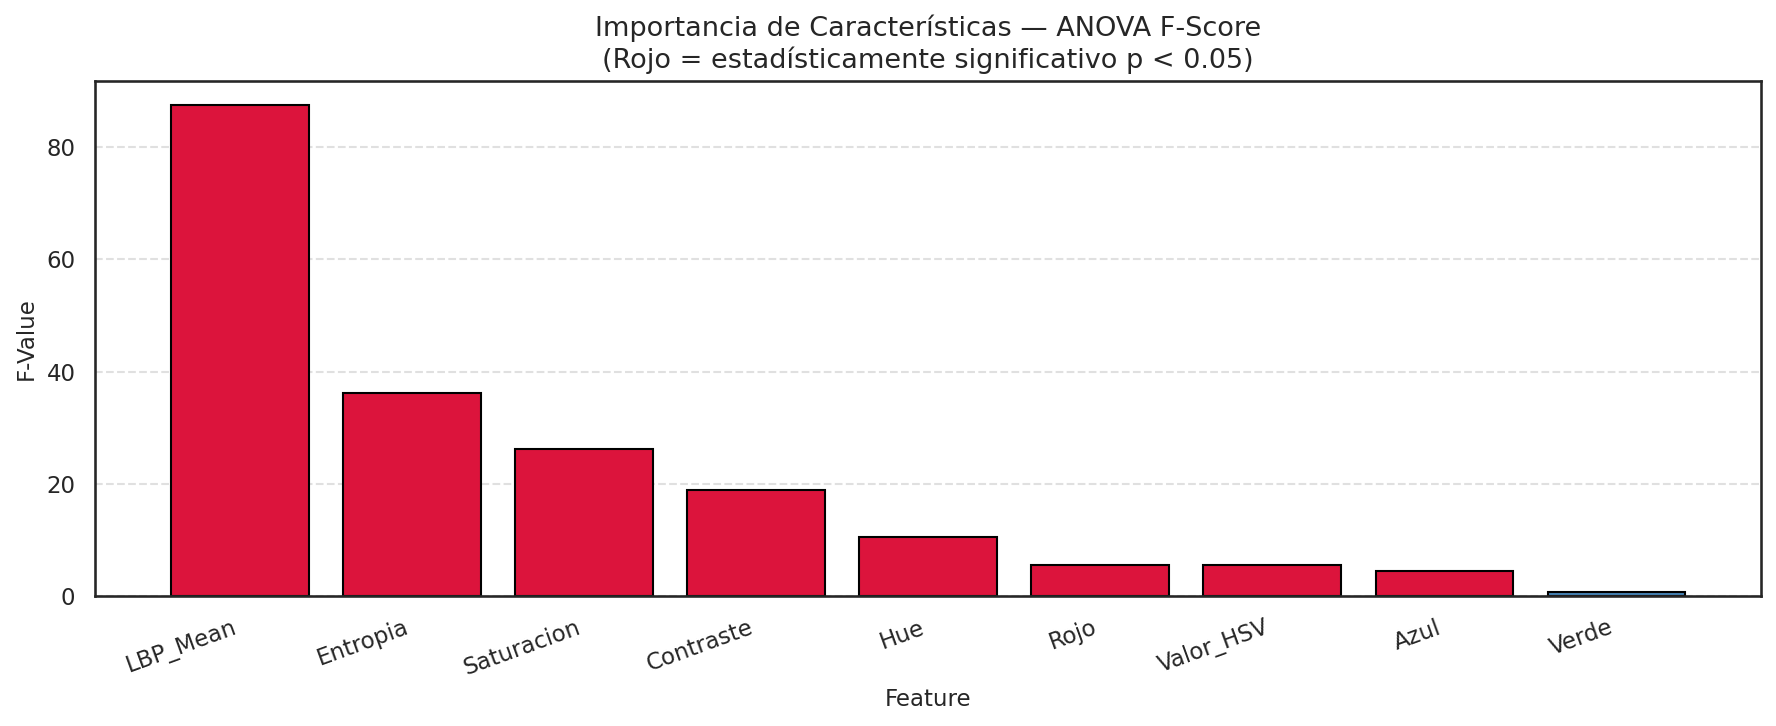


Features seleccionadas (k=5): [np.str_('Contraste'), np.str_('Hue'), np.str_('Saturacion'), np.str_('LBP_Mean'), np.str_('Entropia')]
X_final shape: (2639, 5)


In [22]:
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt

# ── Separamos X y y SIEMPRE desde df_clean ────────────────────────────────────
X_clean = df_clean[columnas_numericas]          # features
y_clean = df_clean['Etiqueta_Num']              # target (numérico)

# ── Escalamiento con RobustScaler (más robusto ante los outliers residuales) ──
# También puedes usar StandardScaler; ambos cumplen el requerimiento
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X_clean)

print(f"Dimensiones: X_scaled={X_scaled.shape} | y_clean={y_clean.shape}")
# ▲ Deben coincidir — este era tu error: antes usabas 'y' (df_proyecto) en vez de y_clean

# ── SelectKBest con ANOVA ─────────────────────────────────────────────────────
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled, y_clean)          # ← y_clean, NO y

# ── Visualización de importancia ──────────────────────────────────────────────
scores_df = pd.DataFrame({
    'Feature': columnas_numericas,
    'F_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values('F_Score', ascending=False)

print("\nRanking de características:")
print(scores_df.to_string(index=False))

plt.figure(figsize=(12, 5))
colores = ['crimson' if p < 0.05 else 'steelblue'
           for p in scores_df['P_Value']]
plt.bar(scores_df['Feature'], scores_df['F_Score'],
        color=colores, edgecolor='black')
plt.title("Importancia de Características — ANOVA F-Score\n"
          "(Rojo = estadísticamente significativo p < 0.05)", fontsize=13)
plt.xlabel("Feature", fontsize=11)
plt.ylabel("F-Value", fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Seleccionamos las K mejores (ej. k=5) para el modelo final ────────────────
K_MEJOR = 5
selector_k = SelectKBest(score_func=f_classif, k=K_MEJOR)
X_final    = selector_k.fit_transform(X_scaled, y_clean)
features_seleccionadas = np.array(columnas_numericas)[selector_k.get_support()]

print(f"\nFeatures seleccionadas (k={K_MEJOR}): {list(features_seleccionadas)}")
print(f"X_final shape: {X_final.shape}")

3. Ajuste de Pesos para Clases Minoritarias. Esta es la parte clave que solicitaste. En lugar de borrar datos o inventar imágenes, le diremos al modelo que "preste más atención" (asigne más penalización al error) cuando se equivoque en categorías con pocas muestras, como Whiteheads.

In [23]:
from sklearn.utils.class_weight import compute_class_weight

# ── Calculamos sobre y_clean (dataset limpio), no sobre y original ────────────
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_clean),
    y=y_clean
)

dict_weights = {i: round(w, 4) for i, w in enumerate(weights)}

print("Pesos por clase:")
for clase_num, clase_nom in enumerate(le.classes_):
    print(f"  {clase_num} ({clase_nom:>15s}): {dict_weights[clase_num]:.4f}")

Pesos por clase:
  0 (     Blackheads): 0.7455
  1 (           Cyst): 0.8365
  2 (        Papules): 0.8667
  3 (       Pustules): 0.9163
  4 (     Whiteheads): 4.5896


4. Stratified K-Fold

In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# ── Configuración del CV estratificado ───────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Modelo base con pesos de clase incorporados ───────────────────────────────
modelo = RandomForestClassifier(
    n_estimators=200,
    class_weight=dict_weights,   # manejo del desbalance
    random_state=42,
    n_jobs=-1
)

# ── Evaluación cruzada estratificada ─────────────────────────────────────────
scores = cross_val_score(
    modelo, X_final, y_clean,
    cv=skf,
    scoring='balanced_accuracy',   # métrica adecuada para desbalance
    n_jobs=-1
)

print(f"\nStratified K-Fold (k=5) — Balanced Accuracy por fold:")
for i, s in enumerate(scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Media : {scores.mean():.4f}")
print(f"  Std   : {scores.std():.4f}")

# ── Verificación de estratificación (distribución por fold) ──────────────────
print("\nDistribución de clases por fold:")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_final, y_clean), 1):
    dist = pd.Series(y_clean.iloc[val_idx]).value_counts().sort_index()
    print(f"  Fold {fold}: { {le.classes_[k]: v for k, v in dist.items()} }")


Stratified K-Fold (k=5) — Balanced Accuracy por fold:
  Fold 1: 0.7274
  Fold 2: 0.7182
  Fold 3: 0.7470
  Fold 4: 0.7347
  Fold 5: 0.7321

  Media : 0.7319
  Std   : 0.0094

Distribución de clases por fold:
  Fold 1: {'Blackheads': 142, 'Cyst': 126, 'Papules': 122, 'Pustules': 115, 'Whiteheads': 23}
  Fold 2: {'Blackheads': 142, 'Cyst': 126, 'Papules': 122, 'Pustules': 115, 'Whiteheads': 23}
  Fold 3: {'Blackheads': 142, 'Cyst': 126, 'Papules': 122, 'Pustules': 115, 'Whiteheads': 23}
  Fold 4: {'Blackheads': 141, 'Cyst': 127, 'Papules': 121, 'Pustules': 116, 'Whiteheads': 23}
  Fold 5: {'Blackheads': 141, 'Cyst': 126, 'Papules': 122, 'Pustules': 115, 'Whiteheads': 23}


In [25]:
import joblib

# ── Lo que tu compañero necesita para entrenar ────────────────────────────────

# 1. Arrays listos para el modelo
np.save('X_final.npy', X_final)       # (2639, 5) — features seleccionadas y escaladas
np.save('y_clean.npy', y_clean.values) # (2639,)  — etiquetas numéricas

# 2. Objetos de preprocesamiento (para que pueda transformar datos nuevos igual)
joblib.dump(scaler,      'scaler.pkl')
joblib.dump(selector_k,  'selector_k.pkl')
joblib.dump(le,          'label_encoder.pkl')

# 3. Configuración del experimento
joblib.dump(dict_weights, 'class_weights.pkl')
joblib.dump(skf,          'stratified_kfold.pkl')

# 4. DataFrame completo por si necesita trazabilidad
df_clean.to_csv('df_clean.csv', index=False)

print("Archivos exportados:")
print("  X_final.npy       — Features para entrenar")
print("  y_clean.npy       — Etiquetas para entrenar")
print("  scaler.pkl        — Para escalar datos nuevos")
print("  selector_k.pkl    — Para seleccionar features en datos nuevos")
print("  label_encoder.pkl — Para decodificar predicciones a nombres")
print("  class_weights.pkl — Pesos para el modelo")
print("  stratified_kfold.pkl — Configuración del CV")
print("  df_clean.csv      — Dataset limpio completo")

Archivos exportados:
  X_final.npy       — Features para entrenar
  y_clean.npy       — Etiquetas para entrenar
  scaler.pkl        — Para escalar datos nuevos
  selector_k.pkl    — Para seleccionar features en datos nuevos
  label_encoder.pkl — Para decodificar predicciones a nombres
  class_weights.pkl — Pesos para el modelo
  stratified_kfold.pkl — Configuración del CV
  df_clean.csv      — Dataset limpio completo


In [26]:
import joblib

# ── Lo que tu compañero necesita para entrenar ────────────────────────────────

# 1. Arrays listos para el modelo
np.save('X_final.npy', X_final)       # (2639, 5) — features seleccionadas y escaladas
np.save('y_clean.npy', y_clean.values) # (2639,)  — etiquetas numéricas

# 2. Objetos de preprocesamiento (para que pueda transformar datos nuevos igual)
joblib.dump(scaler,      'scaler.pkl')
joblib.dump(selector_k,  'selector_k.pkl')
joblib.dump(le,          'label_encoder.pkl')

# 3. Configuración del experimento
joblib.dump(dict_weights, 'class_weights.pkl')
joblib.dump(skf,          'stratified_kfold.pkl')

# 4. DataFrame completo por si necesita trazabilidad
df_clean.to_csv('df_clean.csv', index=False)

print("Archivos exportados:")
print("  X_final.npy       — Features para entrenar")
print("  y_clean.npy       — Etiquetas para entrenar")
print("  scaler.pkl        — Para escalar datos nuevos")
print("  selector_k.pkl    — Para seleccionar features en datos nuevos")
print("  label_encoder.pkl — Para decodificar predicciones a nombres")
print("  class_weights.pkl — Pesos para el modelo")
print("  stratified_kfold.pkl — Configuración del CV")
print("  df_clean.csv      — Dataset limpio completo")

Archivos exportados:
  X_final.npy       — Features para entrenar
  y_clean.npy       — Etiquetas para entrenar
  scaler.pkl        — Para escalar datos nuevos
  selector_k.pkl    — Para seleccionar features en datos nuevos
  label_encoder.pkl — Para decodificar predicciones a nombres
  class_weights.pkl — Pesos para el modelo
  stratified_kfold.pkl — Configuración del CV
  df_clean.csv      — Dataset limpio completo


In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# ==========================================
# 1. Configuración del modelo y CV
# ==========================================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

modelo = RandomForestClassifier(
    n_estimators=200,
    class_weight=dict_weights,
    random_state=42,
    n_jobs=-1
)

# ==========================================
# 2. Evaluación SIN Feature Selection
# (Todas las 9 features escaladas)
# ==========================================
scores_sin_fs = cross_val_score(
    modelo,
    X_scaled,
    y_clean,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1
)

# ==========================================
# 3. Evaluación CON Feature Selection
# (Top 5 features)
# ==========================================
scores_con_fs = cross_val_score(
    modelo,
    X_final,
    y_clean,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1
)

# ==========================================
# 4. Tabla comparativa
# ==========================================
tabla_comparacion = pd.DataFrame({
    'Configuración': [
        'Sin Feature Selection',
        'Con SelectKBest (K=5)'
    ],
    'Balanced Accuracy Promedio': [
        round(scores_sin_fs.mean(), 4),
        round(scores_con_fs.mean(), 4)
    ],
    'Desviación Estándar': [
        round(scores_sin_fs.std(), 4),
        round(scores_con_fs.std(), 4)
    ]
})

print(tabla_comparacion)

           Configuración  Balanced Accuracy Promedio  Desviación Estándar
0  Sin Feature Selection                      0.7209               0.0163
1  Con SelectKBest (K=5)                      0.7319               0.0094


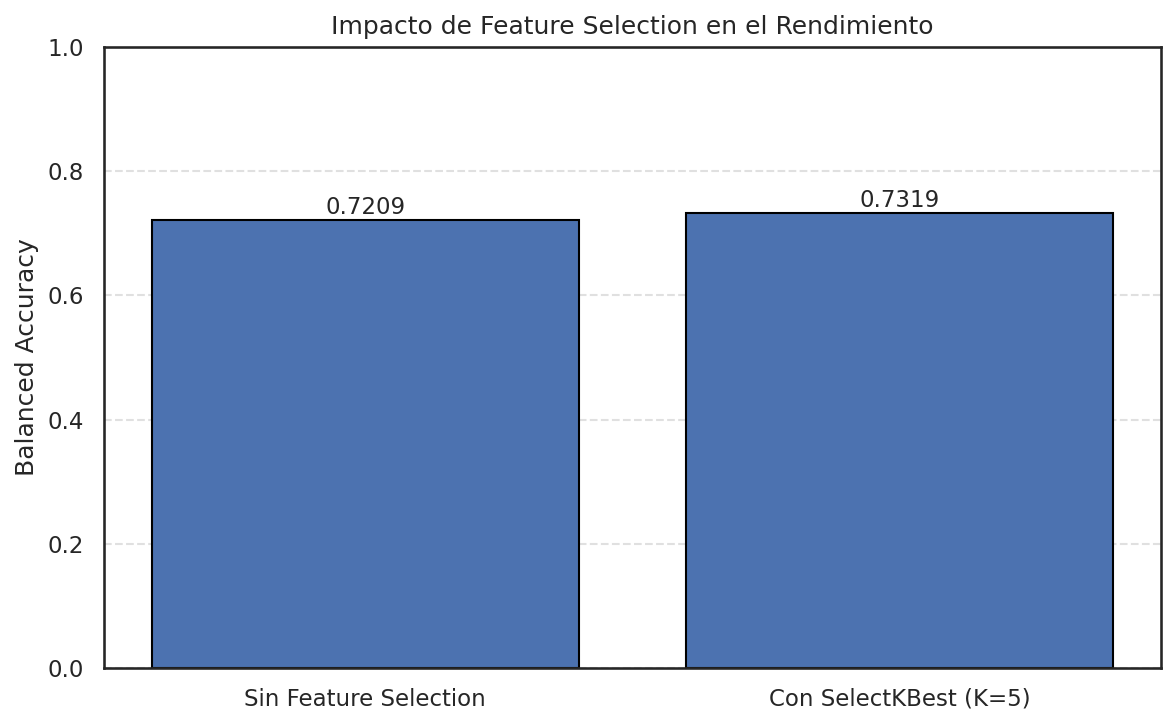

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    tabla_comparacion['Configuración'],
    tabla_comparacion['Balanced Accuracy Promedio'],
    edgecolor='black'
)

plt.title('Impacto de Feature Selection en el Rendimiento')
plt.ylabel('Balanced Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, v in enumerate(tabla_comparacion['Balanced Accuracy Promedio']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# 4.